# Malimg Dataset
The dataset consists of 9339 image files for 25 different malware families. The dataset is organized in folders, where each folder contains all samples for a single malware family. The folder name corresponds to the malware family's name.

## Exploring the Dataset

In [5]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

DATA_BASE_PATH = "./malimg_paper_dataset_imgs/"

In [6]:
# compute the class distribution
dist = {}
for mlw_class in os.listdir(DATA_BASE_PATH):
    mlw_dir = os.path.join(DATA_BASE_PATH, mlw_class)
    dist[mlw_class] = len(os.listdir(mlw_dir))

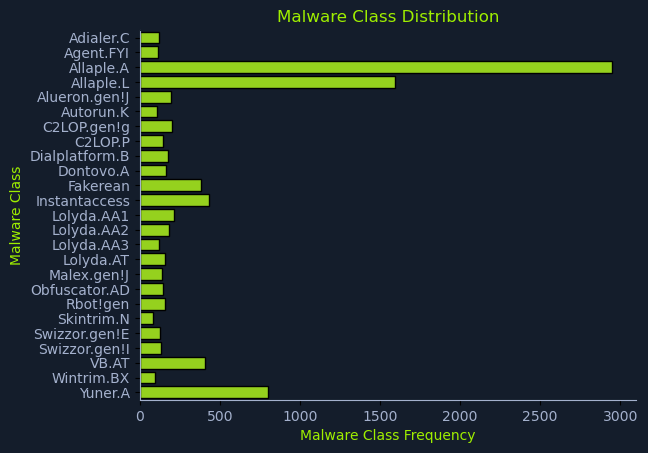

In [7]:
# plot the class distribution

# HTB Color Palette
htb_green = "#9FEF00"
node_black = "#141D2B"
hacker_grey = "#A4B1CD"

# data
classes = list(dist.keys())
frequencies = list(dist.values())

# plot
plt.figure(facecolor=node_black)
sns.barplot(y=classes, x=frequencies, edgecolor = "black", orient='h', color=htb_green)
plt.title("Malware Class Distribution", color=htb_green)
plt.xlabel("Malware Class Frequency", color=htb_green)
plt.ylabel("Malware Class", color=htb_green)
plt.xticks(color=hacker_grey)
plt.yticks(color=hacker_grey)
ax = plt.gca()
ax.set_facecolor(node_black)
ax.spines['bottom'].set_color(hacker_grey)
ax.spines['top'].set_color(node_black)
ax.spines['right'].set_color(node_black)
ax.spines['left'].set_color(hacker_grey)
plt.show()

# Preprocessing the Malware Dataset
Before training, we split our data into train/test sets, apply model-specific preprocessing, and wrap everything in DataLoaders for efficient batching during training and inference.

## Preparing the Datasets
To split the data into two distinct datasets, one for training and one for testing, we will use the library split-folders.

The test folder contains the test dataset, the train folder contains the training dataset, and the val folder contains the validation dataset. In this case, we will not use a validation data set, which is why the validation data set is empty.

In [8]:
import splitfolders

DATA_BASE_PATH = "./malimg_paper_dataset_imgs/"  # source dataset with class subfolders
TARGET_BASE_PATH = "./newdata/"                  # destination for split output
TRAINING_RATIO = 0.8
TEST_RATIO = 1 - TRAINING_RATIO                  # 0.2 — no validation split

# splits into train/ and test/ subdirs, preserving class folder structure
splitfolders.ratio(input=DATA_BASE_PATH, output=TARGET_BASE_PATH, ratio=(TRAINING_RATIO, 0, TEST_RATIO))

Copying files: 9339 files [00:12, 745.27 files/s]


## Applying Preprocessing & Creating DataLoaders
Define transforms to resize all images to a consistent shape and normalize pixel values, ensuring stable and efficient CNN training.

In [9]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((75, 75)),                                          # resize all images to 75x75 pixels
    transforms.ToTensor(),                                                # convert PIL image to tensor and scale pixels to [0, 1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406],                     # subtract ImageNet channel means (R, G, B)
                         std=[0.229, 0.224, 0.225])                      # divide by ImageNet channel stds — centers data around 0
])

Afterward, we can load the datasets from their corresponding folders and apply the preprocessing functions.

In [10]:
from torchvision.datasets import ImageFolder
import os

BASE_PATH = "./newdata/"

# Load training and test datasets
train_dataset = ImageFolder(
    root=os.path.join(BASE_PATH, "train"),
    transform=transform
)

test_dataset = ImageFolder(
    root=os.path.join(BASE_PATH, "test"),
    transform=transform
)

Wrap the datasets in DataLoaders to enable batched, parallelized iteration over the data during training and inference.

In [11]:
from torch.utils.data import DataLoader

TRAIN_BATCH_SIZE = 1024
TEST_BATCH_SIZE = 1024

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=2
)
    
test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

Let us take a look at one of the preprocessed images to see its effects.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.169412].


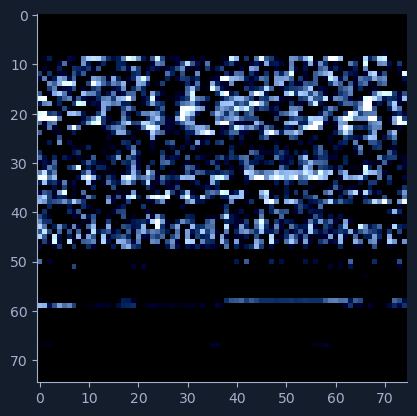

In [12]:
import matplotlib.pyplot as plt

# HTB color palette
htb_green  = "#9FEF00"   # HTB brand green (unused here but available)
node_black = "#141D2B"   # dark background color
hacker_grey = "#A4B1CD"  # muted grey for axes and ticks

# grab the first image tensor from the first batch in train_loader
sample = next(iter(train_loader))[0][0]  # [0] = images in batch, [0] = first image

# set the figure background to HTB dark
plt.figure(facecolor=node_black)

# permute from (C, H, W) → (H, W, C) since matplotlib expects channels last
plt.imshow(sample.permute(1, 2, 0))

# style tick labels in grey
plt.xticks(color=hacker_grey)
plt.yticks(color=hacker_grey)

ax = plt.gca()
ax.set_facecolor(node_black)          # axes background dark
ax.spines['bottom'].set_color(hacker_grey)  # show bottom border in grey
ax.spines['top'].set_color(node_black)      # hide top border (blends into bg)
ax.spines['right'].set_color(node_black)    # hide right border
ax.spines['left'].set_color(hacker_grey)    # show left border in grey
ax.tick_params(axis='x', colors=hacker_grey)
ax.tick_params(axis='y', colors=hacker_grey)

plt.show()

After combining the above code into a single function, we end up with the following code:

In [13]:
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import os

def load_datasets(base_path, train_batch_size, test_batch_size):
    # Define preprocessing transforms
    transform = transforms.Compose([
        transforms.Resize((75, 75)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Load training and test datasets
    train_dataset = ImageFolder(
        root=os.path.join(base_path, "train"),
        transform=transform
    )

    test_dataset = ImageFolder(
        root=os.path.join(base_path, "test"),
        transform=transform
    )

    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=train_batch_size,
        shuffle=True,
        num_workers=2
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=test_batch_size,
        shuffle=False,
        num_workers=2
    )

    n_classes = len(train_dataset.classes)
    return train_loader, test_loader, n_classes

# The Model
The heart of any classifier is the model. As discussed previously, we will be using a CNN model. To speed up the training process, we will base our model on a pre-trained version of a well-established CNN called ResNet50.

## ResNet50
ResNet50 is a 50-layer, 23M-parameter CNN pretrained on ImageNet — we fine-tune it on malware images rather than training from scratch, saving days of compute. To further cut training time, we freeze all layers except the final one, so only the last layer's weights update during training. We also reshape that final layer to output exactly the number of malware classes in our dataset.

In [14]:
import torch.nn as nn
import torchvision.models as models

HIDDEN_LAYER_SIZE = 1000  # neurons in the intermediate layer before the class output

class MalwareClassifier(nn.Module):
    def __init__(self, n_classes):
        super(MalwareClassifier, self).__init__()

        # load ResNet50 with ImageNet pretrained weights as a starting point
        self.resnet = models.resnet50(weights='DEFAULT')

        # freeze all ResNet layers — only the new fc head will train
        for param in self.resnet.parameters():
            param.requires_grad = False

        # replace ResNet's original 1000-class ImageNet head with our own
        num_features = self.resnet.fc.in_features  # output size of the layer before fc (2048 for ResNet50)
        self.resnet.fc = nn.Sequential(
            nn.Linear(num_features, HIDDEN_LAYER_SIZE),  # compress 2048 → 1000
            nn.ReLU(),                                    # non-linearity
            nn.Linear(HIDDEN_LAYER_SIZE, n_classes)       # 1000 → number of malware classes
        )

    def forward(self, x):
        return self.resnet(x)  # single forward pass through the full network

Dynamically pull the class count from the dataset itself so the model's output layer is always correctly sized without hardcoding. We are loading the train/test DataLoaders from disk, then using the automatically detected class count to initialize a ResNet50-based classifier with the correctly sized output layer.

In [15]:
DATA_PATH = "./newdata/"
TRAINING_BATCH_SIZE = 1024
TEST_BATCH_SIZE = 1024

# Load datasets
train_loader, test_loader, n_classes = load_datasets(DATA_PATH, TRAINING_BATCH_SIZE, TEST_BATCH_SIZE)

# Initialize model
model = MalwareClassifier(n_classes)

# Training and Evaluation (Malware Image Classification)

## Training
Define a training loop using CrossEntropyLoss and Adam, iterating over the full training set each epoch to run forward and backward passes.

In [16]:
import torch
import time

def train(model, train_loader, n_epochs, verbose=False):
    model.train()                                        # set model to training mode (enables dropout, batchnorm updates)
    criterion = torch.nn.CrossEntropyLoss()              # loss function for multi-class classification
    optimizer = torch.optim.Adam(model.parameters())    # Adam optimizer — only unfrozen params will update
    training_data = {"accuracy": [], "loss": []}        # track metrics per epoch for plotting later
    for epoch in range(n_epochs):
        running_loss = 0
        n_total = 0
        n_correct = 0
        checkpoint = time.time() * 1000                 # epoch start time in ms
        for inputs, labels in train_loader:
            optimizer.zero_grad()                       # clear gradients from previous batch
            outputs = model(inputs)                     # forward pass — get class logits
            loss = criterion(outputs, labels)           # compute loss between predictions and ground truth
            loss.backward()                             # backprop — compute gradients
            optimizer.step()                            # update unfrozen weights using gradients
            _, predicted = outputs.max(1)               # take highest logit as predicted class
            n_total += labels.size(0)                   # accumulate total samples seen
            n_correct += predicted.eq(labels).sum().item()  # accumulate correct predictions
            running_loss += loss.item()                 # accumulate batch loss
        epoch_loss = running_loss / len(train_loader)   # average loss across all batches
        epoch_duration = int(time.time() * 1000 - checkpoint)  # ms elapsed this epoch
        epoch_accuracy = compute_accuracy(n_correct, n_total)
        training_data["accuracy"].append(epoch_accuracy)
        training_data["loss"].append(epoch_loss)
        if verbose:
            print(f"[i] Epoch {epoch+1} of {n_epochs}: Acc: {epoch_accuracy:.2f}% Loss: {epoch_loss:.4f} (Took {epoch_duration} ms).")
    return training_data

## Save the model

In [17]:
def save_model(model, path):
    model_cpu = model.cpu()
    model_scripted = torch.jit.script(model_cpu)
    model_scripted.save(path)

## Evaluation
To evaluate the model, we will first define a function that runs the model on a single input and returns the predicted class.

In [18]:
def predict(model, test_data):
    model.eval()
    with torch.no_grad():
        output = model(test_data)
        _, predicted = torch.max(output.data, 1)
    return predicted

Switch the model to eval mode and disable gradient computation, then iterate the test set to measure classification accuracy.

In [19]:
def compute_accuracy(n_correct, n_total):
    return round(100 * n_correct / n_total, 2)

In [20]:
def evaluate(model, test_loader):
    model.eval()

    n_correct = 0
    n_total = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            predicted = predict(model, data)
            n_total += target.size(0)
            n_correct += (predicted == target).sum().item()

    accuracy = compute_accuracy(n_correct, n_total)  

    return accuracy

## Plots
Lastly, let us define a couple of helper functions that create simple plots for the training accuracy and loss per epoch, respectively.

In [21]:
import matplotlib.pyplot as plt

def plot(data, title, label, xlabel, ylabel):
    # HTB Color Palette
    htb_green = "#9FEF00"
    node_black = "#141D2B"
    hacker_grey = "#A4B1CD"

    # plot
    plt.figure(figsize=(10, 6), facecolor=node_black)
    plt.plot(range(1, len(data)+1), data, label=label, color=htb_green)
    plt.title(title, color=htb_green)
    plt.xlabel(xlabel, color=htb_green)
    plt.ylabel(ylabel, color=htb_green)
    plt.xticks(color=hacker_grey)
    plt.yticks(color=hacker_grey)
    ax = plt.gca()
    ax.set_facecolor(node_black)
    ax.spines['bottom'].set_color(hacker_grey)
    ax.spines['top'].set_color(node_black)
    ax.spines['right'].set_color(node_black)
    ax.spines['left'].set_color(hacker_grey)

    legend = plt.legend(facecolor=node_black, edgecolor=hacker_grey, fontsize=10)
    plt.setp(legend.get_texts(), color=htb_green)
    
    plt.show()

def plot_training_accuracy(training_data):
    plot(training_data['accuracy'], "Training Accuracy", "Accuracy", "Epoch", "Accuracy (%)")

def plot_training_loss(training_data):
    plot(training_data['loss'], "Training Loss", "Loss", "Epoch", "Loss")

## Running the Code
After defining all helper functions, we can write a script that defines all parameters and runs the helper functions to load the data, initialize the model, train the model, save the model, and finally evaluate the model.

[i] Starting Training...
[i] Epoch 1 of 10: Acc: 58.91% Loss: 1.4595 (Took 59201 ms).
[i] Epoch 2 of 10: Acc: 87.00% Loss: 0.4249 (Took 56185 ms).
[i] Epoch 3 of 10: Acc: 90.82% Loss: 0.2669 (Took 55800 ms).
[i] Epoch 4 of 10: Acc: 92.48% Loss: 0.2101 (Took 55629 ms).
[i] Epoch 5 of 10: Acc: 94.02% Loss: 0.1771 (Took 55723 ms).
[i] Epoch 6 of 10: Acc: 95.04% Loss: 0.1466 (Took 55709 ms).
[i] Epoch 7 of 10: Acc: 95.63% Loss: 0.1339 (Took 55647 ms).
[i] Epoch 8 of 10: Acc: 96.34% Loss: 0.1184 (Took 55577 ms).
[i] Epoch 9 of 10: Acc: 96.90% Loss: 0.1013 (Took 55627 ms).
[i] Epoch 10 of 10: Acc: 97.39% Loss: 0.0881 (Took 55527 ms).
[i] Inference accuracy: 88.99%.


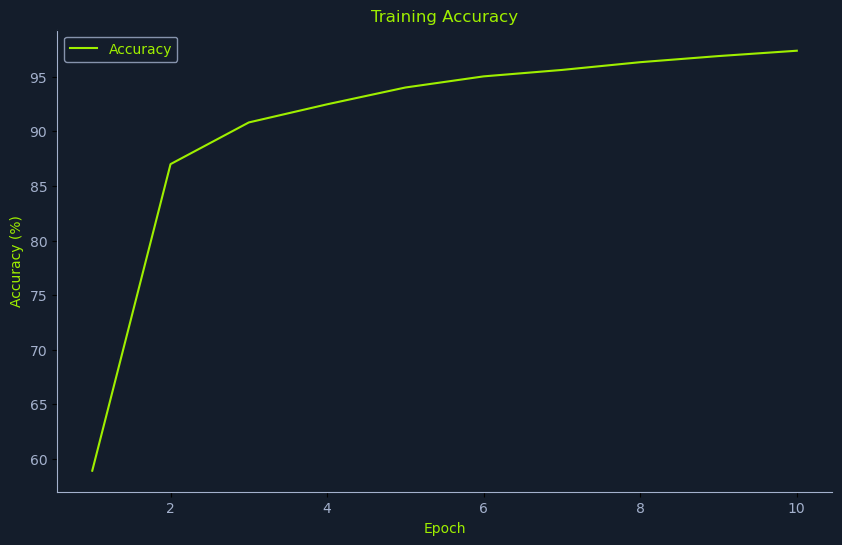

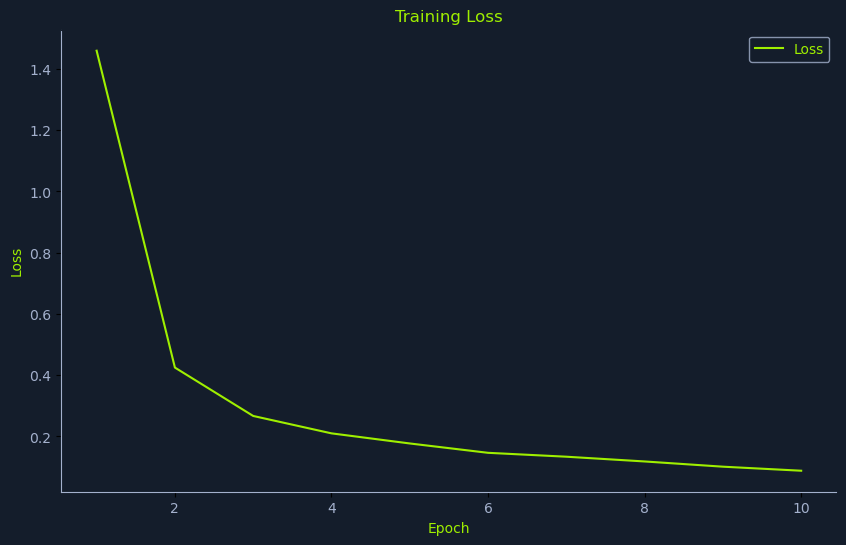

In [22]:
# data parameters
DATA_PATH = "./newdata/"
N_EPOCHS = 10
TRAINING_BATCH_SIZE = 512
TEST_BATCH_SIZE = 1024
HIDDEN_LAYER_SIZE = 1000
MODEL_FILE = "malware_classifier.pth"

# Load datasets
train_loader, test_loader, n_classes = load_datasets(DATA_PATH, TRAINING_BATCH_SIZE, TEST_BATCH_SIZE)

# Initialize model
model = MalwareClassifier(n_classes)

# Train model
print("[i] Starting Training...")  
training_information = train(model, train_loader, N_EPOCHS, verbose=True)

# Save model
save_model(model, MODEL_FILE)

# evaluate model
accuracy = evaluate(model, test_loader)
print(f"[i] Inference accuracy: {accuracy}%.")  

# Plot training details
plot_training_accuracy(training_information)
plot_training_loss(training_information)

## Evaluate Model Only

[i] Inference accuracy: 88.99%.


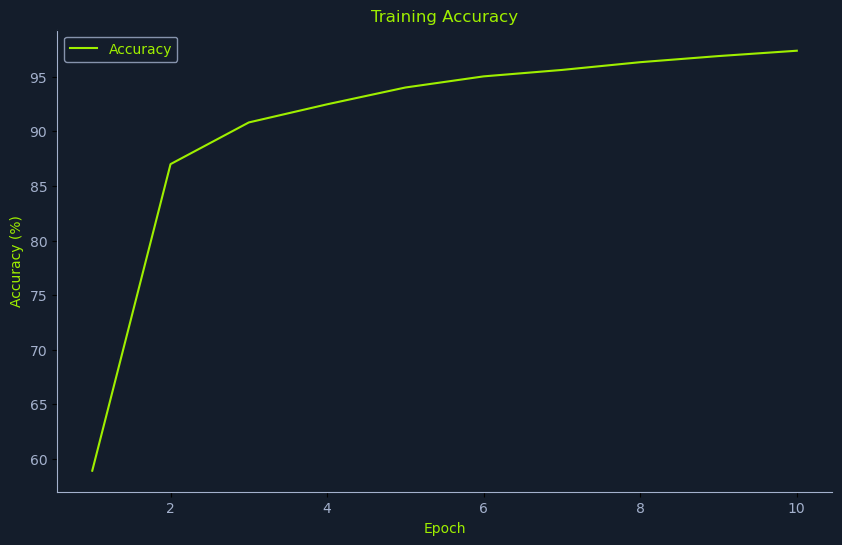

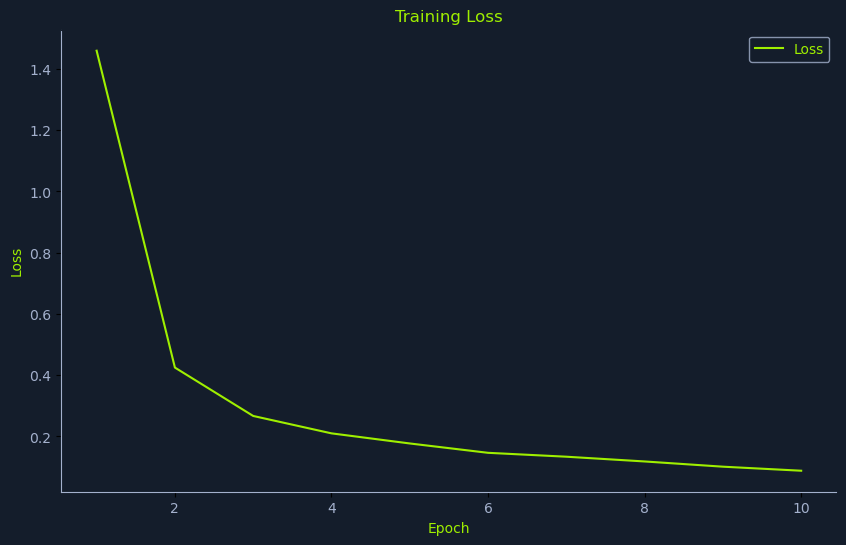

In [23]:
accuracy = evaluate(model, test_loader)
print(f"[i] Inference accuracy: {accuracy}%.")
plot_training_accuracy(training_information)
plot_training_loss(training_information)